We infer the underlying parameters of the membrane potential using the V1-V2 simulataneous spike recordings data from Adam Kohn's lab.

In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Literal
import warnings # To handle potential warnings gracefully

In [2]:
# Load the MATLAB file
# fileloc = '../../data/2019/105l001p16.mat' 
# fileloc = '../../data/2019/106r001p26.mat'
# fileloc = '../../data/2019/106r002p70.mat'
fileloc = '../../data/2019/107l002p67.mat'
# fileloc = '../../data/2019/107l003p143.mat'
matlab_data = scipy.io.loadmat(fileloc)

In [3]:
# Define constants for better readability (column indices for V1/V2)
V1_SPIKE_COL = 0
V2_SPIKE_COL = 1

def load_kohn_lab_spikes(
    file_path: str,
    data_type: Literal['evoked', 'spontaneous'] = 'evoked'
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Loads V1 and V2 spike data from Kohn Lab MATLAB (.mat) files.

    Assumes a specific structure within the .mat file:
    - Data is stored under the key 'neuralData'.
    - neuralData[0, 0][0] contains spike data in a cell array-like structure.
      Each row represents a recording, alternating between evoked and spontaneous.
    - Even rows (0, 2, 4, ...) correspond to evoked trials ('main recordings').
    - Odd rows (1, 3, 5, ...) correspond to spontaneous trials.
    - Column V1_SPIKE_COL (0) contains V1 spikes (often as sparse matrices).
    - Column V2_SPIKE_COL (1) contains V2 spikes (often as sparse matrices).

    Args:
        file_path (str): Path to the .mat file.
        data_type (Literal['evoked', 'spontaneous']): Type of data to load.
            Defaults to 'evoked'.

    Returns:
        Tuple[np.ndarray, np.ndarray]: A tuple containing:
        - spikes1 (np.ndarray): V1 spike data with shape
                                (num_trials, num_neurons_V1, time_bins).
        - spikes2 (np.ndarray): V2 spike data with shape
                                (num_trials, num_neurons_V2, time_bins).

    Raises:
        ValueError: If data_type is not 'evoked' or 'spontaneous'.
        FileNotFoundError: If the file_path does not exist.
        KeyError, IndexError, TypeError: If the .mat file structure deviates
                                         from the expected format.
    """
    if data_type not in ['evoked', 'spontaneous']:
        raise ValueError("data_type must be either 'evoked' or 'spontaneous'")

    # Load the MATLAB file
    try:
        matlab_data = scipy.io.loadmat(file_path)
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        raise # Re-raise the exception for calling code to handle

    try:
        # Navigate the structure loaded by scipy.io.loadmat
        # Adjust indices if your specific .mat file structure differs
        neural_data_struct = matlab_data['neuralData'][0, 0]

        stim = neural_data_struct[1].squeeze()[0::2]

        # Assuming the spike data cell array is the first element (index 0)
        raw_spike_data_array = neural_data_struct[0]

        num_total_recordings = raw_spike_data_array.shape[0]

        # Check if the number of recordings is even (expected for pairs)
        if num_total_recordings % 2 != 0:
            warnings.warn(f"Warning: Odd number of recordings found ({num_total_recordings}). "
                          "This might indicate unexpected data structure or an incomplete pair. "
                          "Processing pairs based on integer division.", UserWarning)

        num_trial_pairs = num_total_recordings // 2

        # Determine the row offset based on the desired data type
        # Evoked trials are at indices 0, 2, 4, ... (offset 0)
        # Spontaneous trials are at indices 1, 3, 5, ... (offset 1)
        row_offset = 0 if data_type == 'evoked' else 1

        spikes1_list = []
        spikes2_list = []

        for i in range(num_trial_pairs):
            # Calculate the actual row index in the raw data array
            trial_row_index = 2 * i + row_offset

            # Extract, convert from sparse (if necessary), and type cast V1 data
            v1_raw = raw_spike_data_array[trial_row_index, V1_SPIKE_COL]
            if scipy.sparse.issparse(v1_raw):
                v1_dense = v1_raw.toarray()
            else: # Assume it's already dense or an array-like object
                v1_dense = np.asarray(v1_raw)
            spikes1_list.append(v1_dense.astype(np.int8))

            # Extract, convert from sparse (if necessary), and type cast V2 data
            v2_raw = raw_spike_data_array[trial_row_index, V2_SPIKE_COL]
            if scipy.sparse.issparse(v2_raw):
                v2_dense = v2_raw.toarray()
            else: # Assume it's already dense or an array-like object
                v2_dense = np.asarray(v2_raw)
            spikes2_list.append(v2_dense.astype(np.int8))

        # Stack the lists of trial data into final NumPy arrays
        # np.stack adds a new dimension at the beginning (axis=0)
        spikes1 = np.stack(spikes1_list, axis=0)
        spikes2 = np.stack(spikes2_list, axis=0)

    except (KeyError, IndexError, TypeError) as e:
        print(f"Error processing data structure in {file_path}. "
              "The .mat file might not have the expected 'neuralData' structure.")
        print(f"Specific error: {e}")
        raise

    return stim, spikes1, spikes2


In [ ]:
# location where the spiking data is stored
fileloc = '../../data/2019/107l002p67.mat'

# Load evoked data (default behavior)
print(f"Loading EVOKED data from: {fileloc}")
stim, v1_evoked, v2_evoked = load_kohn_lab_spikes(file_path=fileloc, data_type='evoked')
print("Evoked Data Shapes:")
print(f"  V1 (spikes1): {v1_evoked.shape}") # (num_trials, num_neurons_V1, time_bins)
print(f"  V2 (spikes2): {v2_evoked.shape}") # (num_trials, num_neurons_V2, time_bins)
print("-" * 20)

# Load spontaneous data
print(f"Loading SPONTANEOUS data from: {fileloc}")
stim, v1_spont, v2_spont = load_kohn_lab_spikes(file_path=fileloc, data_type='spontaneous')
print("Spontaneous Data Shapes:")
print(f"  V1 (spikes1): {v1_spont.shape}")
print(f"  V2 (spikes2): {v2_spont.shape}")
print("-" * 20)


Loading EVOKED data from: ../../data/2019/107l002p67.mat
Evoked Data Shapes:
  V1 (spikes1): (3200, 97, 1280)
  V2 (spikes2): (3200, 31, 1280)
--------------------
Loading SPONTANEOUS data from: ../../data/2019/107l002p67.mat
Spontaneous Data Shapes:
  V1 (spikes1): (3200, 97, 1500)
  V2 (spikes2): (3200, 31, 1500)
--------------------


In [20]:
# spikes1 = v1_evoked
# spikes2 = v2_evoked

spikes1 = v1_spont
spikes2 = v2_spont

stim_indices = {}
for i in range(1, 9):
    stim_indices[i] = np.where(stim == i)[0]

In [25]:
all_data = spikes1
# all_data = spikes2

print(all_data.shape)

mean_spike_counts = []
var_spike_counts = []

for i in range(1,9):
    mean_spike_counts.append(np.mean(np.sum(all_data[stim_indices[i], :, :], axis=2), axis=0))
    var_spike_counts.append(np.var(np.sum(all_data[stim_indices[i], :, :], axis=2), axis=0))

mean_spike_counts = np.array(mean_spike_counts).flatten()
var_spike_counts = np.array(var_spike_counts).flatten()

# print shapes
print(mean_spike_counts.shape)
print(var_spike_counts.shape)

(3200, 97, 1500)
(776,)
(776,)


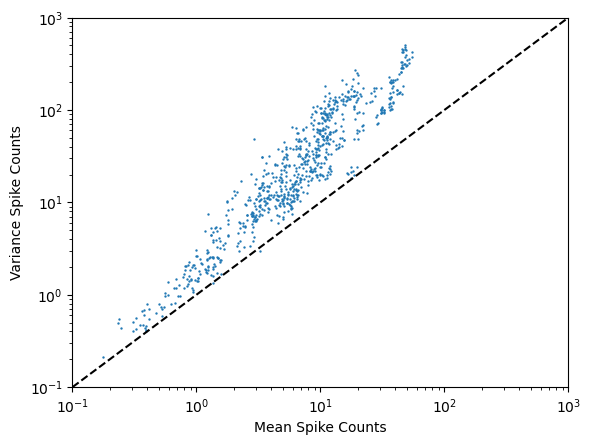

In [26]:
# scatter plot of mean on x axis and variance on y axis alomg with the line y=x in loglog
plt.scatter(mean_spike_counts, var_spike_counts, s=0.5)  # Reduced point size
plt.xscale('log')
plt.yscale('log')
plt.plot([0.1, 1000], [0.1, 1000], '--k')
plt.xlim(0.1, 1000)
plt.ylim(0.1, 1000)
plt.xlabel('Mean Spike Counts')
plt.ylabel('Variance Spike Counts')
plt.show()

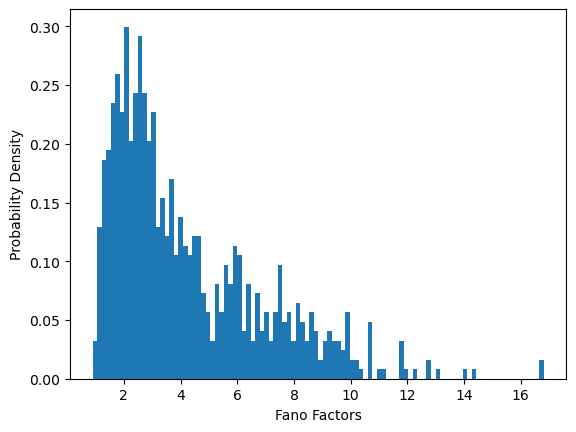

In [27]:
# calculate and plot the probability density of fano factors
fano_factors = var_spike_counts / mean_spike_counts
plt.hist(fano_factors, bins=100, density=True)
plt.xlabel('Fano Factors')
plt.ylabel('Probability Density')
plt.show()